In [1]:
import os, joblib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error, r2_score

os.makedirs("../models", exist_ok=True)

TARGET = "cpi_headline_yoy"
PERSISTENCE = ["cpi_headline_yoy_lag1", "cpi_headline_yoy_lag12"]
MACRO = ["USA_CPI", "iip_general_yoy", "m3_money_supply_yoy", "rbi_repo_rate_yoy_diff"]
COMMODITY = ["wpi_primary_food_articles_yoy", "wpi_manufactured_food_yoy", "wpi_wheat_yoy", "wpi_rice_yoy", "wpi_maize_yoy", "wpi_gram_chana_yoy", "wpi_arhar_tur_yoy", "wpi_moong_yoy", "wpi_urad_yoy", "wpi_masur_yoy", "wpi_tomato_yoy", "wpi_onion_yoy", "wpi_potato_yoy", "wpi_brinjal_yoy", "wpi_cabbage_yoy", "wpi_garlic_yoy", "wpi_mustard_oil_yoy", "wpi_soybean_oil_yoy", "wpi_groundnut_oil_yoy", "wpi_milk_yoy", "wpi_egg_yoy", "wpi_sugar_yoy", "crude_oil_brent_usd_yoy", "palm_oil_usd_yoy", "global_fertilizer_index_yoy"]
CLIMATE = ["rainfall_total_mm", "rainfall_rate_mm_per_day", "temp_mean_celsius", "relative_humidity_2m_pct", "surface_soil_wetness_index", "wind_speed_10m_ms", "solar_irradiance_kwm2", "rainfall_total_mm_anom", "rainfall_rate_mm_per_day_anom", "temp_mean_celsius_anom", "relative_humidity_2m_pct_anom", "surface_soil_wetness_index_anom", "wind_speed_10m_ms_anom", "solar_irradiance_kwm2_anom"]

CONFIGS = {
    "Full": CLIMATE + MACRO + COMMODITY + PERSISTENCE,
    "Climate_only": CLIMATE + PERSISTENCE,
    "Macro_only": MACRO + PERSISTENCE,
    "Commodity_only": COMMODITY + PERSISTENCE
}

In [2]:
train_df = pd.read_csv("../data/train_processed.csv")
test_df = pd.read_csv("../data/test_processed.csv")

X_train, y_train = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_test, y_test = test_df.drop(columns=[TARGET]), test_df[TARGET]


Training SVR: Full
Best Params: {'svr__kernel': 'linear', 'svr__epsilon': 0.2, 'svr__C': 0.05}
TRAIN -> RMSE: 0.5457 | R2: 0.9650
TEST  -> RMSE: 0.9063  | R2: 0.7103


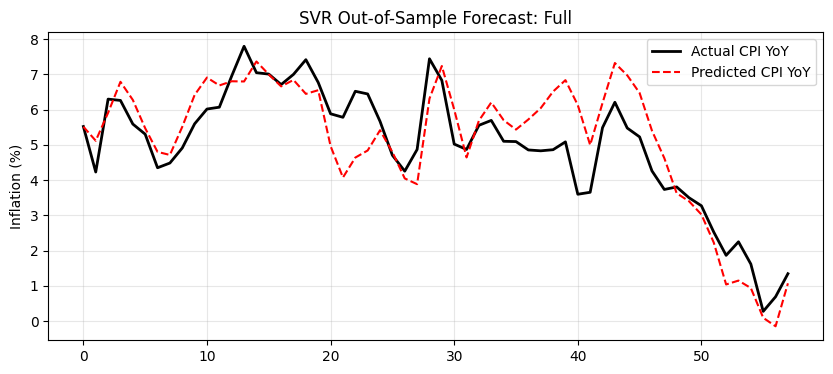


Training SVR: Climate_only
Best Params: {'svr__kernel': 'linear', 'svr__epsilon': 0.3, 'svr__C': 50.0}
TRAIN -> RMSE: 0.7676 | R2: 0.9308
TEST  -> RMSE: 1.1428  | R2: 0.5394


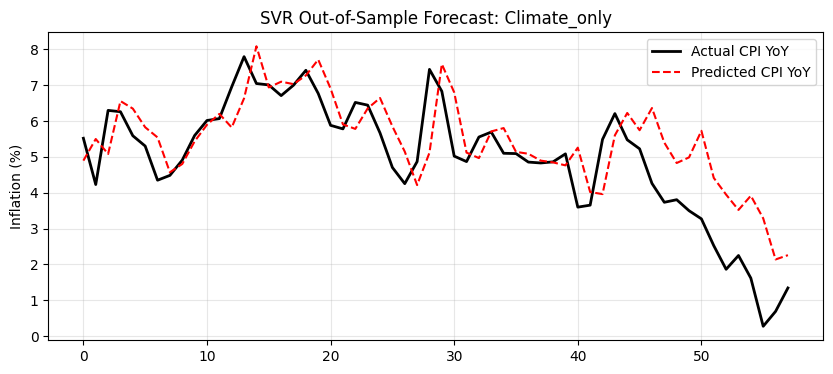


Training SVR: Macro_only
Best Params: {'svr__kernel': 'linear', 'svr__epsilon': 0.1, 'svr__C': 50.0}
TRAIN -> RMSE: 0.7685 | R2: 0.9306
TEST  -> RMSE: 0.7912  | R2: 0.7792


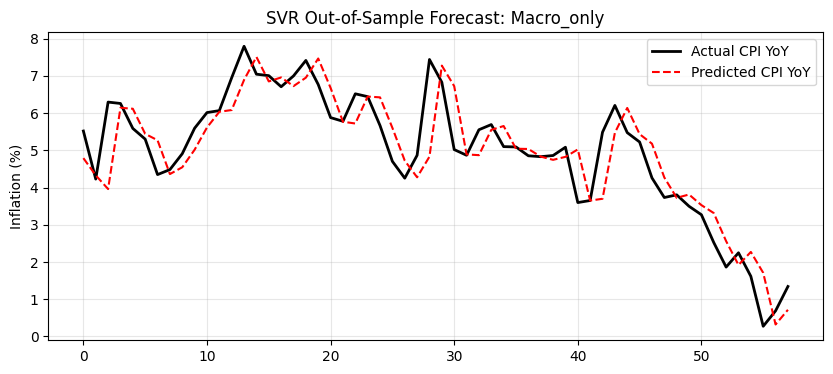


Training SVR: Commodity_only
Best Params: {'svr__kernel': 'linear', 'svr__epsilon': 0.5, 'svr__C': 0.05}
TRAIN -> RMSE: 0.6040 | R2: 0.9571
TEST  -> RMSE: 0.9288  | R2: 0.6957


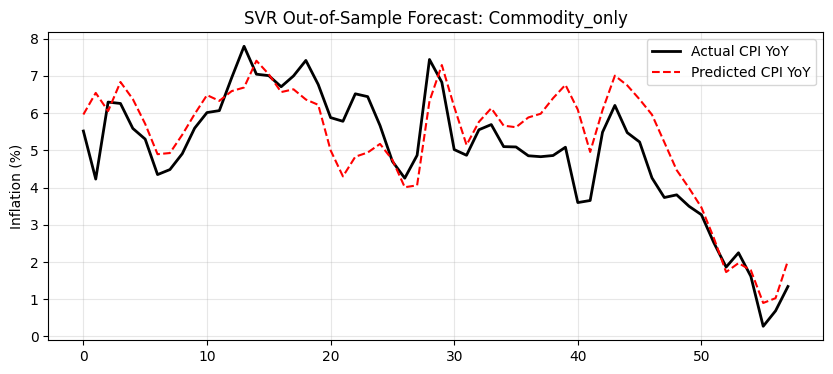

In [3]:
param_distributions = [
    {'svr__kernel': ['rbf'], 'svr__C': [0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0], 'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.05, 0.1], 'svr__epsilon': [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]},
    {'svr__kernel': ['linear'], 'svr__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0], 'svr__epsilon': [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]}
]

pipeline = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])
tscv = TimeSeriesSplit(n_splits=5)

for config_name, features in CONFIGS.items():
    print(f"\n{'='*40}\nTraining SVR: {config_name}\n{'='*40}")
    X_tr_sub, X_te_sub = X_train[features], X_test[features]
    
    # 1. Tune & Train
    search = RandomizedSearchCV(pipeline, param_distributions=param_distributions, n_iter=300, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=42)
    search.fit(X_tr_sub, y_train)
    best_model = search.best_estimator_
    
    # 2. Train & Test Metrics
    y_tr_pred = best_model.predict(X_tr_sub)
    y_te_pred = best_model.predict(X_te_sub)
    
    print(f"Best Params: {search.best_params_}")
    print(f"TRAIN -> RMSE: {root_mean_squared_error(y_train, y_tr_pred):.4f} | R2: {r2_score(y_train, y_tr_pred):.4f}")
    print(f"TEST  -> RMSE: {root_mean_squared_error(y_test, y_te_pred):.4f}  | R2: {r2_score(y_test, y_te_pred):.4f}")
    
    # 3. Plot Actual vs Predicted (Test Set)
    plt.figure(figsize=(10, 4))
    plt.plot(test_df["Date"] if "Date" in test_df else range(len(y_test)), y_test.values, label='Actual CPI YoY', color='black', linewidth=2)
    plt.plot(test_df["Date"] if "Date" in test_df else range(len(y_test)), y_te_pred, label='Predicted CPI YoY', color='red', linestyle='--')
    plt.title(f"SVR Out-of-Sample Forecast: {config_name}")
    plt.ylabel("Inflation (%)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 4. Save Model
    joblib.dump(best_model, f"../models/SVR_{config_name}.joblib")